In [ ]:
import os

print(os.listdir("/content"))

['.config', 'dataset.zip', 'sample_data']


In [ ]:
!unzip -t /content/dataset.zip

Streaming output truncated to the last 5000 lines.
    testing: dataset/labels/train/India_009001.txt   OK
    testing: dataset/labels/train/India_009009.txt   OK
    testing: dataset/labels/train/India_009011.txt   OK
    testing: dataset/labels/train/India_009013.txt   OK
    testing: dataset/labels/train/India_009017.txt   OK
    testing: dataset/labels/train/India_009041.txt   OK
    testing: dataset/labels/train/India_009051.txt   OK
    testing: dataset/labels/train/India_009065.txt   OK
    testing: dataset/labels/train/India_009071.txt   OK
    testing: dataset/labels/train/India_009080.txt   OK
    testing: dataset/labels/train/India_009097.txt   OK
    testing: dataset/labels/train/India_009100.txt   OK
    testing: dataset/labels/train/India_009123.txt   OK
    testing: dataset/labels/train/India_009129.txt   OK
    testing: dataset/labels/train/India_009131.txt   OK
    testing: dataset/labels/train/India_009138.txt   OK
    testing: dataset/labels/train/India_009142.txt   

In [ ]:
!mkdir -p /content/dataset
!unzip -q /content/dataset.zip -d /content/dataset

In [ ]:
!find /content/dataset -maxdepth 2 -type f | head -30

/content/dataset/dataset/data.yaml


In [ ]:
from pathlib import Path
from collections import Counter

labels_dir = Path("/content/dataset/dataset/train/labels")

class_counts = Counter()

for label_file in labels_dir.glob("*.txt"):
    with open(label_file, "r") as f:
        for line in f:
            parts = line.strip().split()
            if parts:
                class_id = int(parts[0])
                class_counts[class_id] += 1

print("Class distribution:")
for class_id, count in sorted(class_counts.items()):
    print(f"Class {class_id}: {count}")

Class distribution:
Class 0: 471
Class 1: 27
Class 2: 23
Class 3: 7
Class 4: 645
Class 5: 3187
Class 6: 5
Class 7: 151
Class 8: 8


In [ ]:
from pathlib import Path
from collections import Counter

labels_dir = Path("/content/dataset/dataset/train/labels")

image_class_counts = Counter()
images_per_class = Counter()

for label_file in labels_dir.glob("*.txt"):
    classes_in_image = set()

    with open(label_file, "r") as f:
        for line in f:
            parts = line.strip().split()
            if parts:
                classes_in_image.add(int(parts[0]))

    for class_id in classes_in_image:
        images_per_class[class_id] += 1

print("Images containing each class:")
for class_id in sorted(images_per_class):
    print(f"Class {class_id}: {images_per_class[class_id]} images")

Images containing each class:
Class 0: 363 images
Class 1: 19 images
Class 2: 22 images
Class 3: 7 images
Class 4: 549 images
Class 5: 1530 images
Class 6: 5 images
Class 7: 124 images
Class 8: 8 images


In [ ]:
from pathlib import Path
from collections import Counter

labels_dir = Path("/content/dataset/dataset/train/labels")

combinations = Counter()

for label_file in labels_dir.glob("*.txt"):
    classes = set()

    with open(label_file, "r") as f:
        for line in f:
            parts = line.strip().split()
            if parts:
                classes.add(int(parts[0]))

    combinations[tuple(sorted(classes))] += 1

print("Class combinations:")
for combo, count in combinations.most_common():
    print(f"{combo}: {count} images")

Class combinations:
(5,): 677 images
(4, 5): 348 images
(0, 5): 176 images
(0, 4, 5): 154 images
(5, 7): 76 images
(4, 5, 7): 29 images
(1, 5): 12 images
(0, 4, 5, 7): 9 images
(0, 2, 5): 8 images
(2, 5): 8 images
(0, 5, 7): 7 images
(0, 2, 4, 5): 5 images
(1, 3, 5): 5 images
(5, 8): 4 images
(4, 5, 6): 3 images
(5, 6): 2 images
(0, 1, 5, 7): 1 images
(2, 4, 5): 1 images
(5, 7, 8): 1 images
(0, 5, 7, 8): 1 images
(0, 1, 3, 5): 1 images
(0, 5, 8): 1 images
(3, 5, 8): 1 images


In [ ]:
!cat /content/dataset/dataset/data.yaml

train: images/train
val: images/val

nc: 9

names:
  0: D00
  1: D01
  2: D10
  3: D11
  4: D20
  5: D40
  6: D43
  7: D44
  8: D50


In [ ]:
from pathlib import Path

for path in [
    "/content/dataset/dataset/images/train",
    "/content/dataset/dataset/labels/train"
]:
    p = Path(path)
    print(path, "→", p.exists(), "| files:", len(list(p.glob("*"))) if p.exists() else 0)

/content/dataset/dataset/images/train → True | files: 1224
/content/dataset/dataset/labels/train → True | files: 1224


In [ ]:
from pathlib import Path
import shutil

original_images = Path("/content/dataset/dataset/images/train")
original_labels = Path("/content/dataset/dataset/labels/train")

balanced_images = Path("/content/dataset/balanced_train/images/train")
balanced_labels = Path("/content/dataset/balanced_train/labels/train")

balanced_images.mkdir(parents=True, exist_ok=True)
balanced_labels.mkdir(parents=True, exist_ok=True)

# Copy original images and labels
for image_file in original_images.iterdir():
    if image_file.is_file():
        shutil.copy2(image_file, balanced_images / image_file.name)

for label_file in original_labels.iterdir():
    if label_file.is_file():
        shutil.copy2(label_file, balanced_labels / label_file.name)

print("Original images copied:", len(list(balanced_images.iterdir())))
print("Original labels copied:", len(list(balanced_labels.iterdir())))

Original images copied: 1224
Original labels copied: 1224


In [ ]:
from pathlib import Path

labels_dir = Path("/content/dataset/dataset/labels/train")

minority_classes = {
    1: "D01",
    2: "D10",
    3: "D11",
    6: "D43",
    8: "D50",
    7: "D44"
}

for class_id, class_name in minority_classes.items():

    files = []

    for label_file in labels_dir.glob("*.txt"):
        with open(label_file, "r") as f:
            classes = [int(line.split()[0]) for line in f if line.strip()]

        if class_id in classes:
            files.append(label_file.stem)

    print(f"{class_name} (class {class_id}): {len(files)} images")

D01 (class 1): 16 images
D10 (class 2): 19 images
D11 (class 3): 6 images
D43 (class 6): 4 images
D50 (class 8): 7 images
D44 (class 7): 98 images


In [ ]:
!pip install -q ultralytics

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.0/46.0 kB 2.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 32.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.2/66.2 kB 6.8 MB/s eta 0:00:00


In [ ]:
import ultralytics

print("Ultralytics version:", ultralytics.__version__)

Creating new Ultralytics Settings v0.0.8 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart#ultralytics-settings.
Ultralytics version: 8.4.136


In [ ]:
from pathlib import Path
import shutil
import random

# Original dataset
original_images = Path("/content/dataset/dataset/images/train")
original_labels = Path("/content/dataset/dataset/labels/train")

# New balanced dataset
balanced_images = Path("/content/dataset/balanced_train/images/train")
balanced_labels = Path("/content/dataset/balanced_train/labels/train")

# Make sure folders exist
balanced_images.mkdir(parents=True, exist_ok=True)
balanced_labels.mkdir(parents=True, exist_ok=True)

# Copy original data
for image_file in original_images.iterdir():
    if image_file.is_file():
        shutil.copy2(image_file, balanced_images / image_file.name)

for label_file in original_labels.iterdir():
    if label_file.is_file():
        shutil.copy2(label_file, balanced_labels / label_file.name)

print("Original dataset copied.")
print("Images:", len(list(balanced_images.glob("*"))))
print("Labels:", len(list(balanced_labels.glob("*"))))

Original dataset copied.
Images: 1224
Labels: 1224


In [ ]:
from pathlib import Path
from collections import defaultdict
import random
import shutil

labels_dir = Path("/content/dataset/dataset/labels/train")
original_images = Path("/content/dataset/dataset/images/train")

balanced_images = Path("/content/dataset/balanced_train/images/train")
balanced_labels = Path("/content/dataset/balanced_train/labels/train")

# Target number of image occurrences for minority classes
targets = {
    1: 50,   # D01
    2: 50,   # D10
    3: 40,   # D11
    6: 40,   # D43
    8: 40,   # D50
    7: 150   # D44
}

# Find images containing each minority class
class_images = defaultdict(list)

for label_file in labels_dir.glob("*.txt"):

    with open(label_file, "r") as f:
        classes = set()

        for line in f:
            if line.strip():
                classes.add(int(line.split()[0]))

    for class_id in targets:
        if class_id in classes:
            class_images[class_id].append(label_file.stem)

# Add controlled copies
for class_id, target in targets.items():

    images = class_images[class_id]

    if not images:
        continue

    current = len(images)

    if current >= target:
        continue

    copies_needed = target - current

    print(
        f"Class {class_id}: "
        f"{current} original images → "
        f"{target} target occurrences"
    )

    for i in range(copies_needed):

        stem = random.choice(images)

        # Find corresponding image
        possible_images = list(original_images.glob(stem + ".*"))

        if not possible_images:
            continue

        image_file = possible_images[0]
        label_file = labels_dir / f"{stem}.txt"

        new_stem = f"{stem}_balance_{class_id}_{i}"

        shutil.copy2(
            image_file,
            balanced_images / f"{new_stem}{image_file.suffix}"
        )

        shutil.copy2(
            label_file,
            balanced_labels / f"{new_stem}.txt"
        )

print("\nBalancing copies created.")
print(
    "Total balanced images:",
    len(list(balanced_images.glob("*")))
)

Class 1: 16 original images → 50 target occurrences
Class 2: 19 original images → 50 target occurrences
Class 3: 6 original images → 40 target occurrences
Class 6: 4 original images → 40 target occurrences
Class 8: 7 original images → 40 target occurrences
Class 7: 98 original images → 150 target occurrences

Balancing copies created.
Total balanced images: 1444


In [ ]:
from pathlib import Path
from collections import Counter

balanced_labels = Path("/content/dataset/balanced_train/labels/train")

class_counts = Counter()
images_per_class = Counter()

for label_file in balanced_labels.glob("*.txt"):

    classes_in_image = set()

    with open(label_file, "r") as f:
        for line in f:
            if line.strip():
                class_id = int(line.split()[0])
                class_counts[class_id] += 1
                classes_in_image.add(class_id)

    for class_id in classes_in_image:
        images_per_class[class_id] += 1

print("=== OBJECT / ANNOTATION COUNTS ===")

for class_id in range(9):
    print(f"Class {class_id}: {class_counts[class_id]}")

print("\n=== IMAGES CONTAINING EACH CLASS ===")

for class_id in range(9):
    print(f"Class {class_id}: {images_per_class[class_id]}")

=== OBJECT / ANNOTATION COUNTS ===
Class 0: 418
Class 1: 115
Class 2: 53
Class 3: 63
Class 4: 565
Class 5: 2895
Class 6: 40
Class 7: 198
Class 8: 45

=== IMAGES CONTAINING EACH CLASS ===
Class 0: 326
Class 1: 80
Class 2: 50
Class 3: 63
Class 4: 484
Class 5: 1444
Class 6: 40
Class 7: 160
Class 8: 45


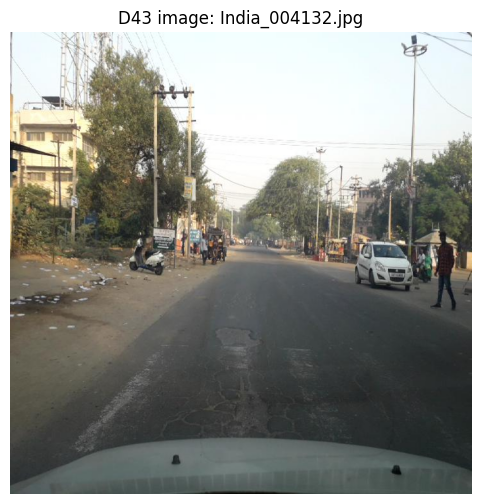

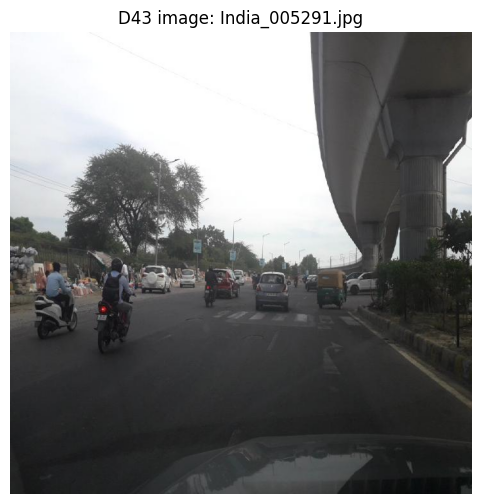

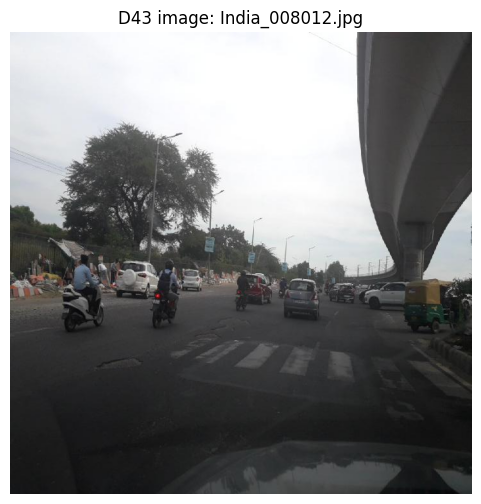

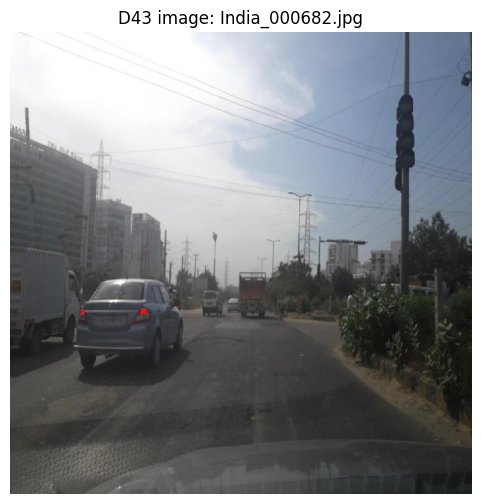

In [ ]:
from pathlib import Path
from PIL import Image
import matplotlib.pyplot as plt

labels_dir = Path("/content/dataset/dataset/labels/train")
images_dir = Path("/content/dataset/dataset/images/train")

class_id = 6  # D43

for label_file in labels_dir.glob("*.txt"):

    with open(label_file, "r") as f:
        classes = [int(line.split()[0]) for line in f if line.strip()]

    if class_id in classes:

        image_path = None

        for ext in [".jpg", ".jpeg", ".png"]:
            candidate = images_dir / (label_file.stem + ext)
            if candidate.exists():
                image_path = candidate
                break

        if image_path:
            img = Image.open(image_path)

            plt.figure(figsize=(6, 6))
            plt.imshow(img)
            plt.title(f"D43 image: {image_path.name}")
            plt.axis("off")
            plt.show()

In [ ]:
from pathlib import Path

yaml_path = Path("/content/dataset/balanced_data.yaml")

yaml_content = """
train: /content/dataset/balanced_train/images/train
val: /content/dataset/dataset/images/val

nc: 9

names:
  0: D00
  1: D01
  2: D10
  3: D11
  4: D20
  5: D40
  6: D43
  7: D44
  8: D50
"""

yaml_path.write_text(yaml_content)

print(yaml_path.read_text())


train: /content/dataset/balanced_train/images/train
val: /content/dataset/dataset/images/val

nc: 9

names:
  0: D00
  1: D01
  2: D10
  3: D11
  4: D20
  5: D40
  6: D43
  7: D44
  8: D50



In [ ]:
from pathlib import Path

train_images = Path("/content/dataset/balanced_train/images/train")
train_labels = Path("/content/dataset/balanced_train/labels/train")

val_images = Path("/content/dataset/dataset/images/val")
val_labels = Path("/content/dataset/dataset/labels/val")

print("Balanced train images:", len(list(train_images.iterdir())))
print("Balanced train labels:", len(list(train_labels.iterdir())))

print("Validation images:", len(list(val_images.iterdir())))
print("Validation labels:", len(list(val_labels.iterdir())))

print("YAML exists:", Path("/content/dataset/balanced_data.yaml").exists())

Balanced train images: 1444
Balanced train labels: 1444
Validation images: 306
Validation labels: 306
YAML exists: True


In [ ]:
from ultralytics import YOLO

model = YOLO("yolo11n.pt")

results = model.train(
    data="/content/dataset/balanced_data.yaml",
    epochs=50,
    imgsz=640,
    batch=16,
    device=0,
    project="/content/runs",
    name="road_damage_balanced",
    seed=42
)

Ultralytics 8.4.136 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/dataset/balanced_data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=road_damage_balanced, nbs=

In [ ]:
metrics = model.val(
    data="/content/dataset/balanced_data.yaml",
    imgsz=640,
    batch=16,
    device=0
)

print("Precision:", metrics.box.mp)
print("Recall:", metrics.box.mr)
print("mAP50:", metrics.box.map50)
print("mAP50-95:", metrics.box.map)

Ultralytics 8.4.136 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLO11n summary (fused): 101 layers, 2,583,907 parameters, 0 gradients, 6.4 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1393.0±416.0 MB/s, size: 66.4 KB)
val: Scanning /content/dataset/dataset/labels/val.cache... 306 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 306/306 80.2Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 20/20 3.7it/s 5.4s
                   all        306        904      0.508      0.407      0.369      0.146
                   D00         73         98      0.366      0.255      0.285      0.145
                   D01          3          4      0.405          1      0.895      0.394
                   D10          3          3          0          0    0.00137   0.000549
                   D11          1          1          1          0          0          0
                   D20        117      

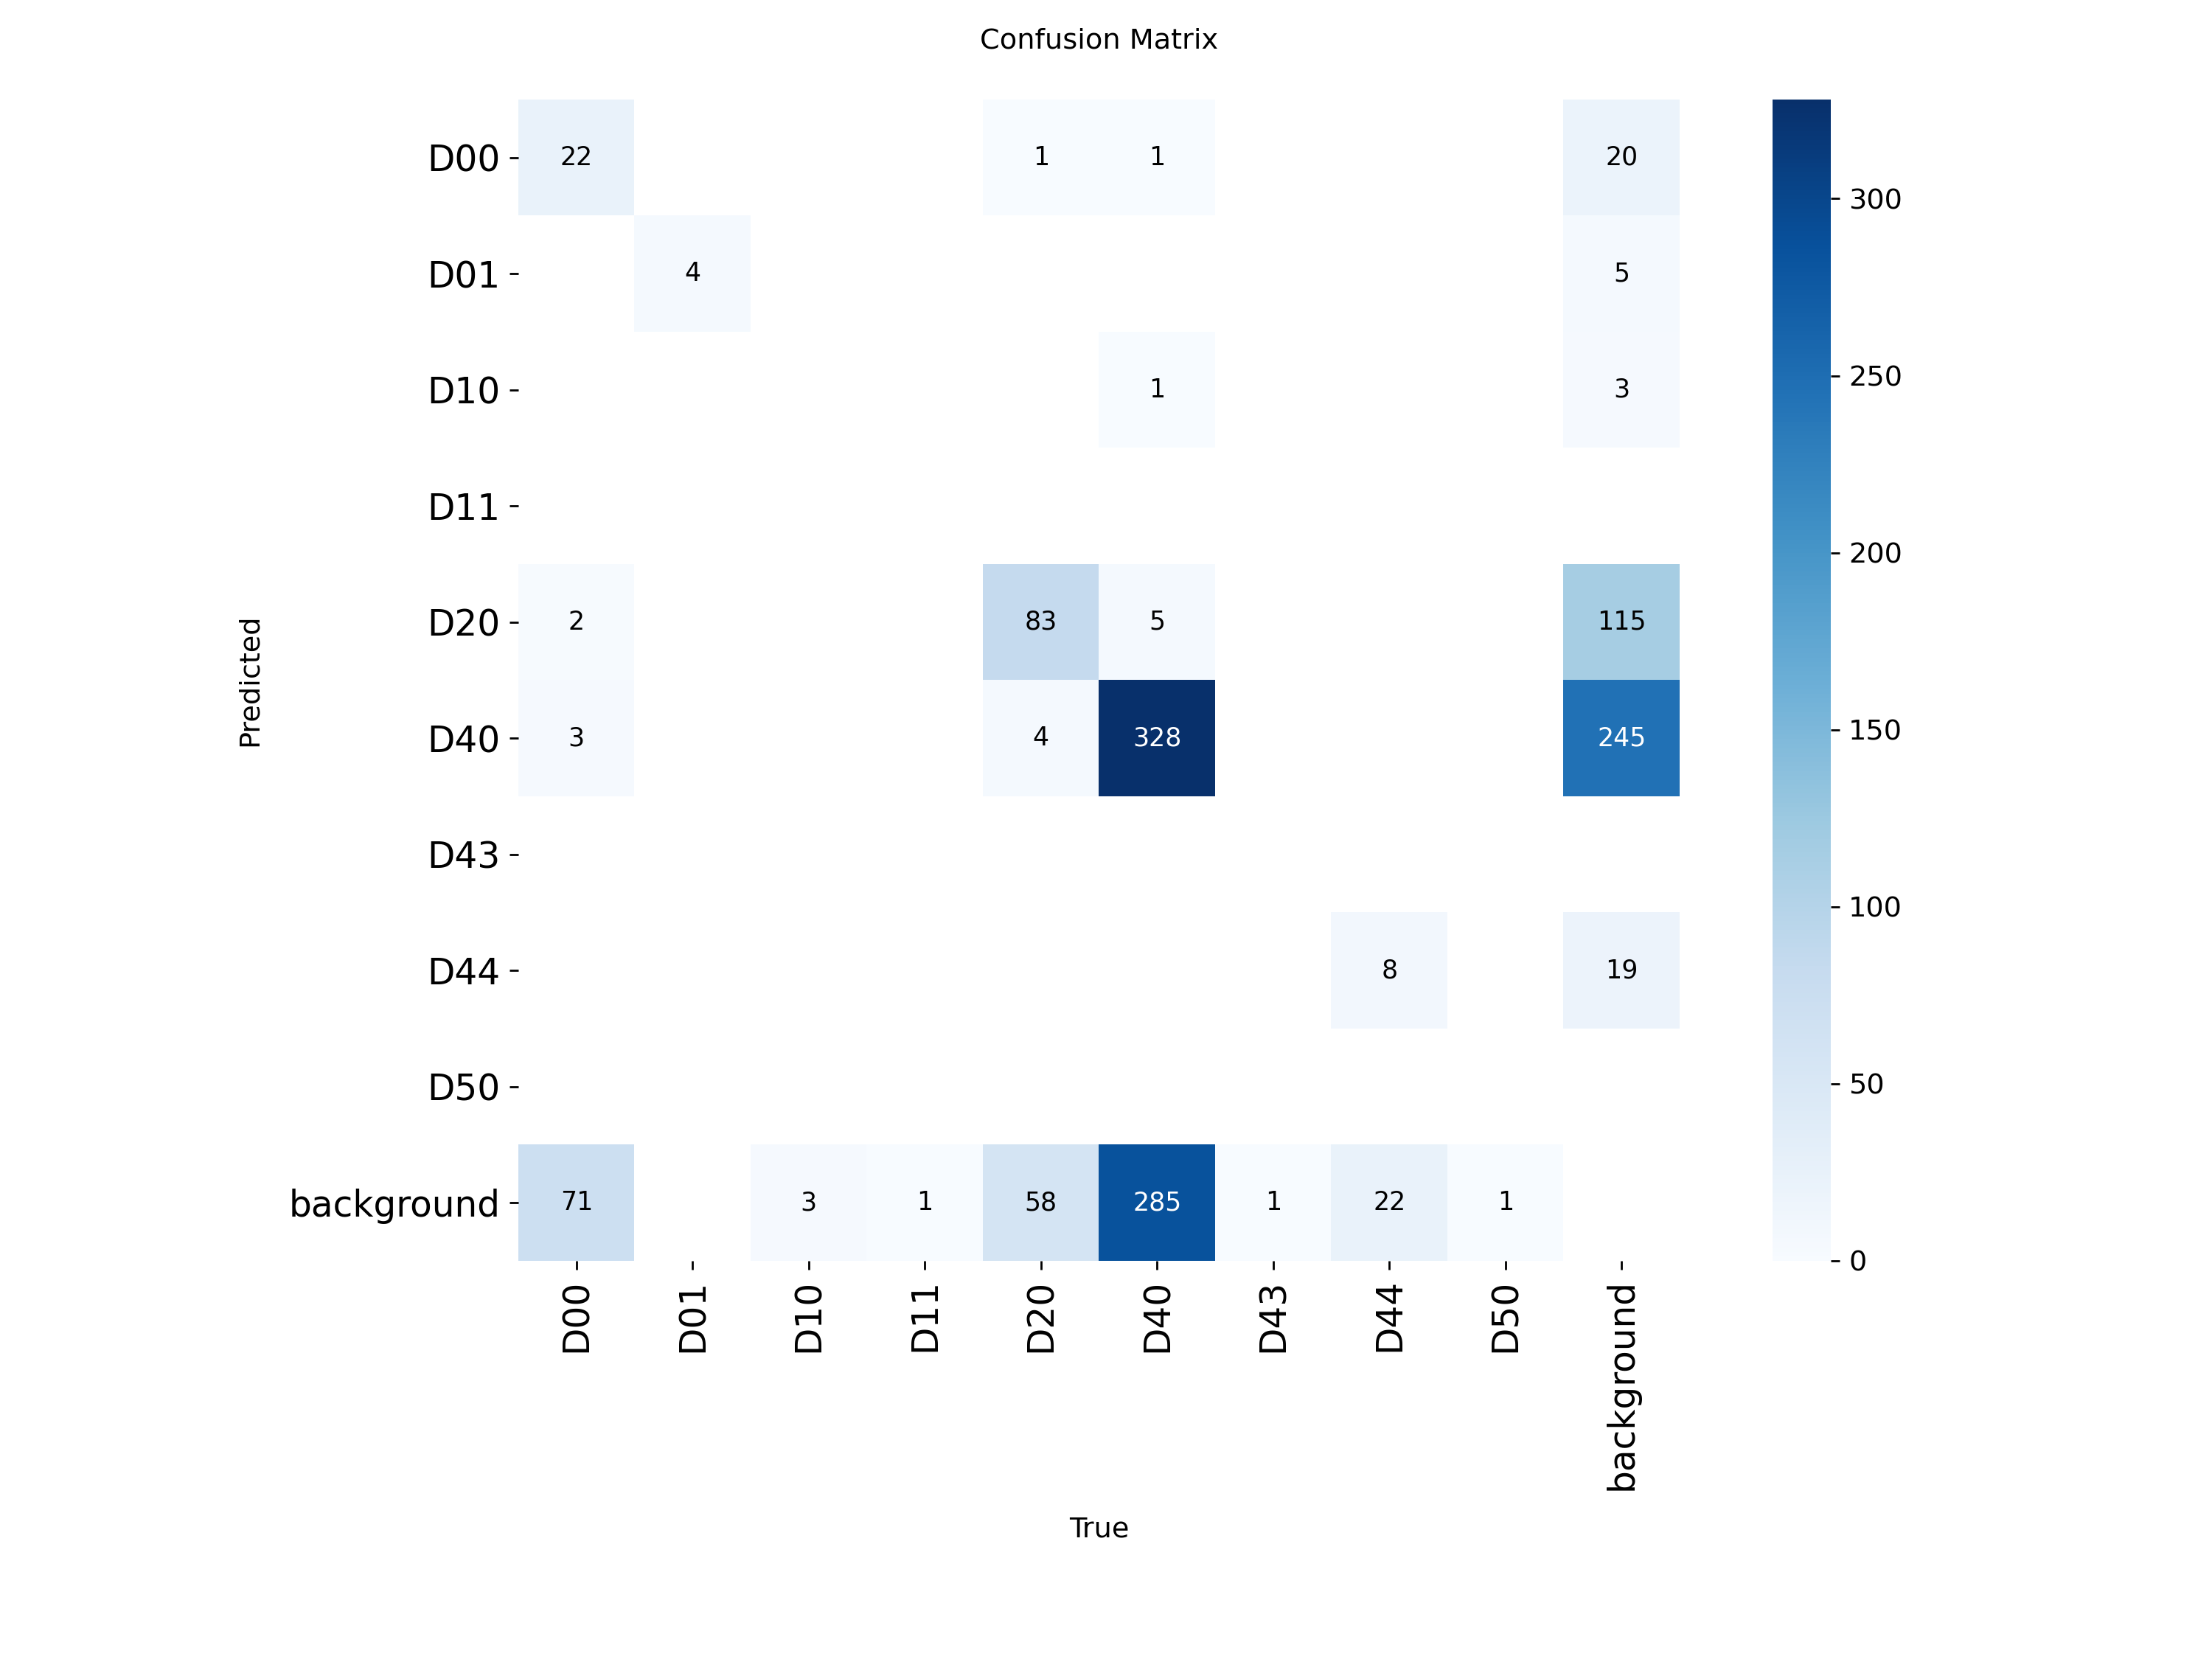

In [ ]:
from IPython.display import Image, display

display(Image(
    filename="/content/runs/road_damage_balanced/confusion_matrix.png",
    width=600
))

In [ ]:
from google.colab import files

files.download("/content/runs/road_damage_balanced/weights/best.pt")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>